In [1]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

df = pd.read_parquet("data/news_with_topics_labeled.parquet")

model_path = "models/sentiment_distilbert_final"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [2]:
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

score_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

def predict_sentiment(text):
    inputs = tokenizer(
        text[:2000],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    
    pred_id = probs.argmax()
    label = label_map[pred_id]
    
    return label, score_map[label], probs.max()

In [3]:
sentiments = []

for text in tqdm(df["article_text"].tolist()):
    label, score, confidence = predict_sentiment(text)
    sentiments.append({
        "sentiment": label,
        "sentiment_score": score,
        "sentiment_confidence": confidence
    })

sent_df = pd.DataFrame(sentiments)

df = pd.concat([df.reset_index(drop=True), sent_df], axis=1)

df.to_parquet("data/news_topics_sentiment.parquet", index=False)

100%|██████████| 30000/30000 [1:53:12<00:00,  4.42it/s]  


Topic-level sentiment

In [4]:
topic_sentiment = (
    df.groupby("topic_label")
    .agg(
        articles=("article_text", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        positive_share=("sentiment", lambda x: (x == "positive").mean()),
        negative_share=("sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

topic_sentiment.to_csv("outputs/topic_sentiment.csv", index=False)

topic_sentiment

,topic_label,articles,avg_sentiment,positive_share,negative_share
1,AI in Finance and Risk Analytics,1334,0.223388,0.257121,0.033733
6,Robotics and Manufacturing Automation,940,0.206383,0.242553,0.036170
2,Generative AI and LLM Adoption,4442,0.197208,0.203287,0.006078
5,Other / Mixed Topic,20543,0.172419,0.211215,0.038797
0,AI Chips and Cloud Infrastructure,537,0.163873,0.204842,0.040968
4,Legal and Professional Services Automation,737,0.109905,0.109905,0.000000
3,Healthcare AI and Diagnostics,1467,0.034765,0.057941,0.023177


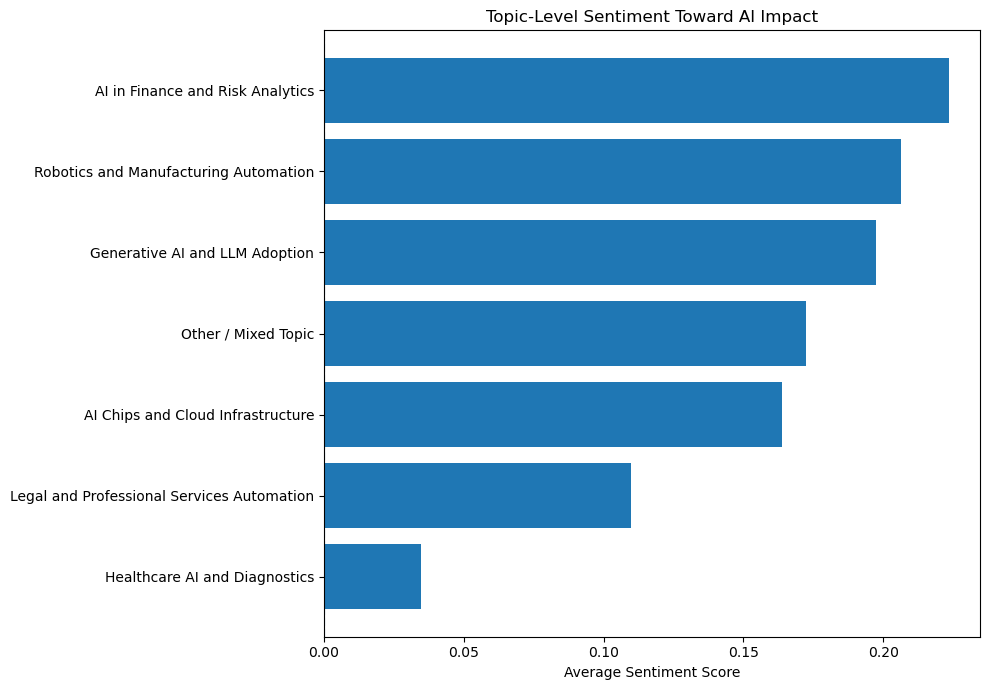

In [5]:
import matplotlib.pyplot as plt

plot_df = topic_sentiment[topic_sentiment["articles"] >= 100].copy()
plot_df = plot_df.sort_values("avg_sentiment")

plt.figure(figsize=(10,7))
plt.barh(plot_df["topic_label"], plot_df["avg_sentiment"])
plt.axvline(0, linestyle="--")
plt.xlabel("Average Sentiment Score")
plt.title("Topic-Level Sentiment Toward AI Impact")
plt.tight_layout()
plt.savefig("figures/topic_sentiment.png", dpi=300)
plt.show()

Entity-level sentiment

In [6]:
entities = pd.read_csv("outputs/entities_all.csv")

df_reset = df.reset_index().rename(columns={"index": "article_id"})

entity_sentiment = entities.merge(
    df_reset[["article_id", "sentiment", "sentiment_score"]],
    on="article_id",
    how="left"
)

entity_summary = (
    entity_sentiment.groupby("entity_clean")
    .agg(
        mentions=("article_id", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        positive_share=("sentiment", lambda x: (x == "positive").mean()),
        negative_share=("sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

entity_summary = entity_summary[entity_summary["mentions"] >= 30]
entity_summary = entity_summary.sort_values("mentions", ascending=False)

entity_summary.to_csv("outputs/entity_sentiment.csv", index=False)

entity_summary.head(30)

,entity_clean,mentions,avg_sentiment,positive_share,negative_share
48497,OpenAI,19734,0.148323,0.200669,0.052346
14702,ChatGPT,16979,0.124094,0.175158,0.051063
28961,Google,13210,0.161166,0.210068,0.048902
42932,Microsoft,11173,0.193592,0.250515,0.056923
6328,Apple,5669,0.179220,0.228612,0.049391
42599,Meta,4480,0.143973,0.198884,0.054911
47582,Nvidia,4252,0.281750,0.356068,0.074318
5470,Amazon,3415,0.189165,0.236603,0.047438
45616,Nasdaq,3329,0.072695,0.111445,0.038750
6093,Anthropic,2702,0.205403,0.236491,0.031088


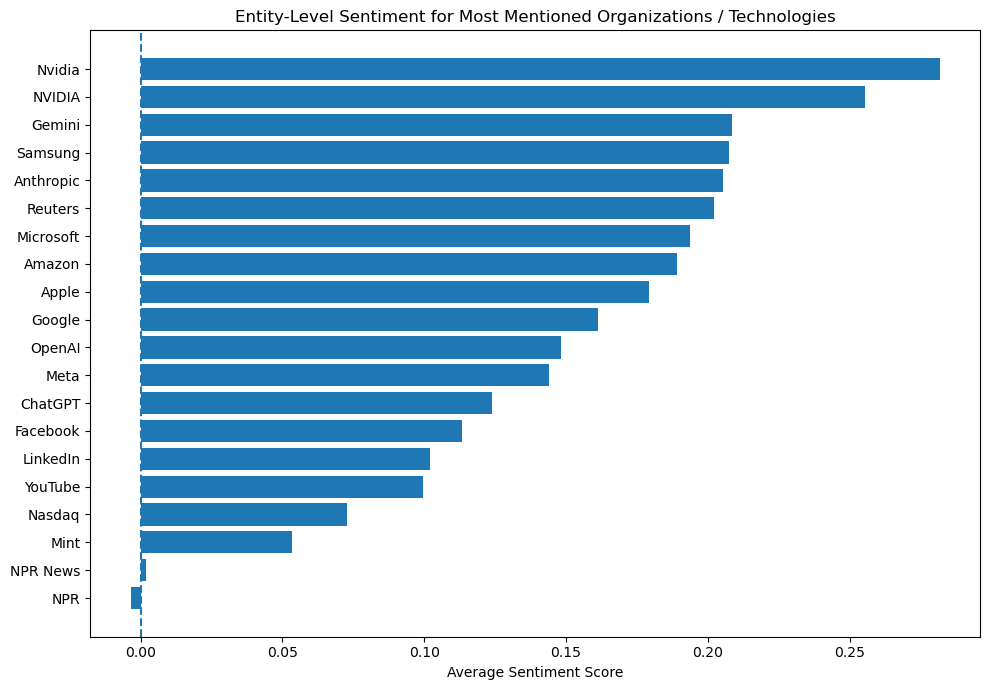

In [7]:
top_entity_sentiment = entity_summary.sort_values("mentions", ascending=False).head(20)
top_entity_sentiment = top_entity_sentiment.sort_values("avg_sentiment")

plt.figure(figsize=(10,7))
plt.barh(top_entity_sentiment["entity_clean"], top_entity_sentiment["avg_sentiment"])
plt.axvline(0, linestyle="--")
plt.xlabel("Average Sentiment Score")
plt.title("Entity-Level Sentiment for Most Mentioned Organizations / Technologies")
plt.tight_layout()
plt.savefig("figures/entity_sentiment.png", dpi=300)
plt.show()

Sentiment over time

In [8]:
df.columns

Index(['url', 'date', 'language', 'title', 'text', 'article_text', 'text_len',
       'is_ai_related', 'topic', 'topic_prob', 'topic_label', 'sentiment',
       'sentiment_score', 'sentiment_confidence'],
      dtype='object')

In [9]:
DATE_COL = "date"

In [10]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

df_time = df.dropna(subset=[DATE_COL]).copy()
df_time["month"] = df_time[DATE_COL].dt.to_period("M").dt.to_timestamp()

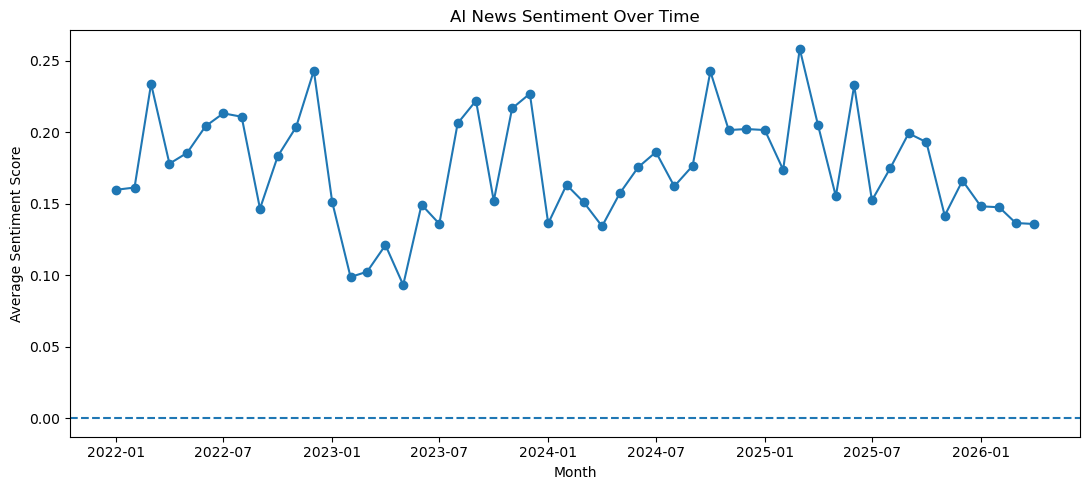

In [11]:
monthly_sentiment = (
    df_time.groupby("month")
    .agg(
        articles=("article_text", "count"),
        avg_sentiment=("sentiment_score", "mean")
    )
    .reset_index()
)

monthly_sentiment.to_csv("outputs/monthly_sentiment.csv", index=False)

plt.figure(figsize=(11,5))
plt.plot(monthly_sentiment["month"], monthly_sentiment["avg_sentiment"], marker="o")
plt.axhline(0, linestyle="--")
plt.ylabel("Average Sentiment Score")
plt.xlabel("Month")
plt.title("AI News Sentiment Over Time")
plt.tight_layout()
plt.savefig("figures/sentiment_over_time.png", dpi=300)
plt.show()

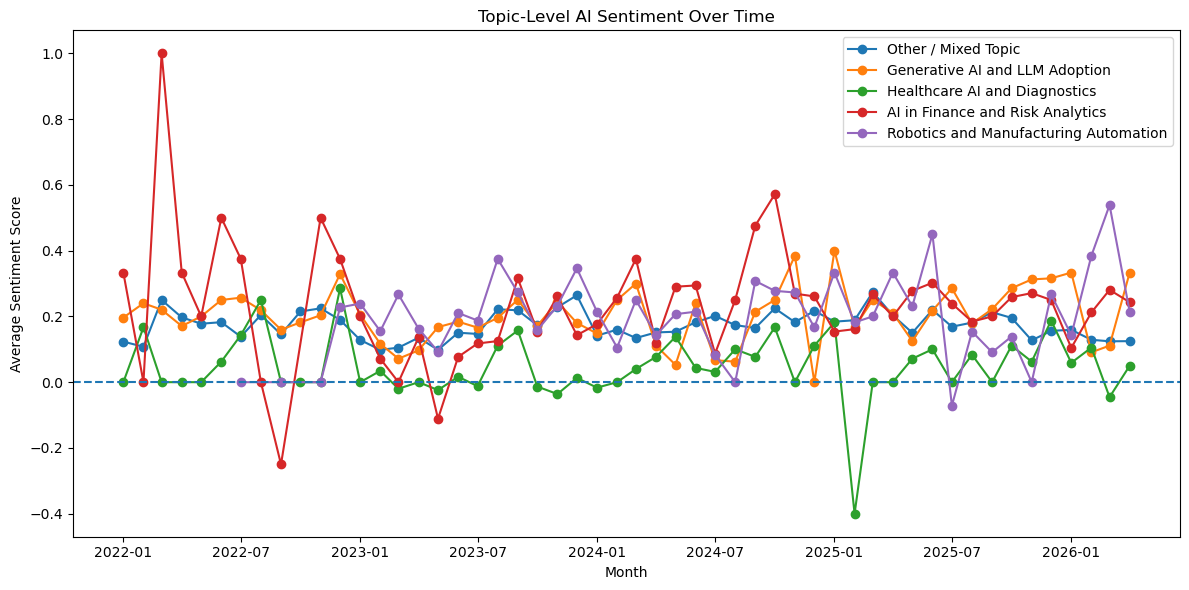

In [12]:
top_topic_labels = (
    df_time["topic_label"]
    .value_counts()
    .head(5)
    .index
)

topic_time = (
    df_time[df_time["topic_label"].isin(top_topic_labels)]
    .groupby(["month", "topic_label"])
    .agg(avg_sentiment=("sentiment_score", "mean"))
    .reset_index()
)

plt.figure(figsize=(12,6))

for topic in top_topic_labels:
    tmp = topic_time[topic_time["topic_label"] == topic]
    plt.plot(tmp["month"], tmp["avg_sentiment"], marker="o", label=topic)

plt.axhline(0, linestyle="--")
plt.ylabel("Average Sentiment Score")
plt.xlabel("Month")
plt.title("Topic-Level AI Sentiment Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("figures/topic_sentiment_over_time.png", dpi=300)
plt.show()